# Hypothesis 7: useful performance exists below the full path dimension

We sweep target dimensions on a logarithmic grid and compare accuracy, output storage, and serialized model size. A useful plateau means a smaller dimension is within two percentage points of the best observed accuracy.

In [1]:
import sys
import pickle
from pathlib import Path
notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists(): notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))
import matplotlib.pyplot as plt
import pandas as pd
from _hypothesis_utils import classification_data, classification_score, downstream_classifier, forest_sketch

,mean_accuracy,std_accuracy,mean_output_mb,mean_model_mb
dimension,,,,
8,0.575,0.035,0.081,2.881
16,0.618,0.006,0.161,3.872
32,0.635,0.043,0.322,6.351
64,0.688,0.021,0.645,10.251


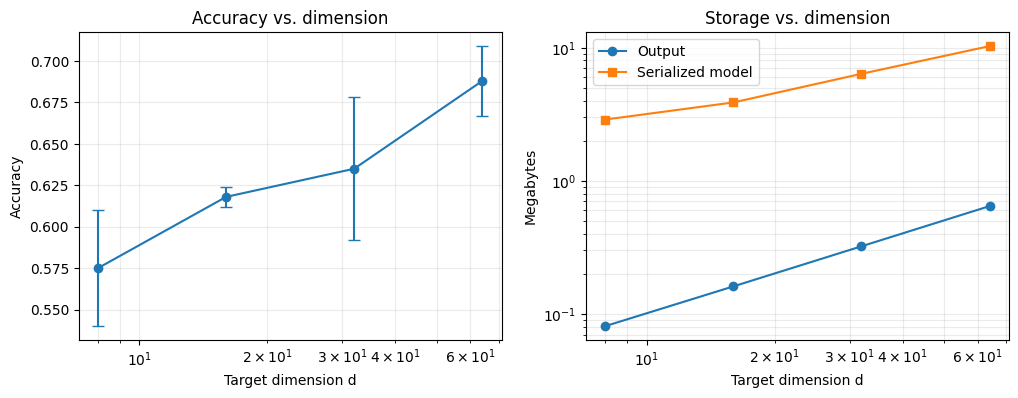

Hypothesis 7: NOT SUPPORTED — smallest dimension within 0.02 of best=64


In [2]:
rows = []
for seed in [0, 1]:
    X_train, _, X_test, y_train, _, y_test = classification_data(seed)
    for dimension in [8, 16, 32, 64]:
        representation = forest_sketch(seed, dimension, 2)
        X_train_view = representation.fit_transform(X_train, y_train)
        X_test_view = representation.transform(X_test)
        accuracy, errors = classification_score(downstream_classifier(seed), X_train_view, y_train, X_test_view, y_test)
        rows.append({'seed': seed, 'dimension': dimension, 'accuracy': accuracy, 'errors': errors, 'output_mb': X_train_view.nbytes / 2**20, 'model_mb': len(pickle.dumps(representation, protocol=pickle.HIGHEST_PROTOCOL)) / 2**20})
results = pd.DataFrame(rows)
summary = results.groupby('dimension').agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'), mean_output_mb=('output_mb', 'mean'), mean_model_mb=('model_mb', 'mean')).round(3)
display(summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(summary.index, summary.mean_accuracy, yerr=summary.std_accuracy, marker='o', capsize=4)
axes[0].set(xscale='log', xlabel='Target dimension d', ylabel='Accuracy', title='Accuracy vs. dimension')
axes[1].plot(summary.index, summary.mean_output_mb, marker='o', label='Output')
axes[1].plot(summary.index, summary.mean_model_mb, marker='s', label='Serialized model')
axes[1].set(xscale='log', yscale='log', xlabel='Target dimension d', ylabel='Megabytes', title='Storage vs. dimension')
axes[1].legend()
for axis in axes: axis.grid(alpha=0.25, which='both')
plt.show()
best = summary.mean_accuracy.max()
smallest_near_best = summary[summary.mean_accuracy >= best - 0.02].index.min()
supported = smallest_near_best < summary.index.max()
print(f'Hypothesis 7: {"SUPPORTED" if supported else "NOT SUPPORTED"} — smallest dimension within 0.02 of best={smallest_near_best}')